# **EEG-Based Multi-Class Emotion Recognition Using Machine Learning**

# 1. Problem Statement

### This project focuses on recognizing human emotions from EEG signals by classifying them into five categories: Happy (1), Sad (2), Neutral (3), Angry (4), and Fear (5). EEG signals are complex, high-dimensional, and often noisy, making accurate emotion classification challenging. The goal is to preprocess the data, extract meaningful features, and train machine learning models such as Support Vector Machine (SVM) and Random Forest, using cross-validation during training to ensure robust performance. The models will be evaluated to identify the best-performing approach for automated emotion recognition, enabling applications in affective computing, mental health monitoring, and brain-computer interfaces.

# 2. Data Acquisition

In [1]:
# Import Libraries

from google.colab import drive
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Connect with my drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [3]:
# Import dataset
os.chdir("/content/drive/MyDrive/Healthcare")
df = pd.read_excel('EEG-data.xlsx')
print(df.head(5))

   Unnamed: 0   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X4086  X4087  \
0           0  -56  -50  -64  -91 -135 -140 -134 -114 -115  ...    -37    -43   
1           1   14   25   31   36   33   33   27   27   21  ...    -45    -32   
2           2 -159 -176 -174 -145 -101  -45    0   29   15  ...    -40    -25   
3           3   34   31   29   19   16   12    3   -1   -5  ...    -34    -33   
4           4   44   50   46   43   43   46   45   40   36  ...      4      5   

   X4088  X4089  X4090  X4091  X4092  X4093  X4094  y  
0    -63    -82   -114   -138   -159   -172   -180  5  
1     -6     -7     -2    -20    -34    -40    -40  5  
2     14     56     73     48    -12    -62   -100  4  
3    -29    -22    -18    -14    -10     -9      0  3  
4      6      6      2      1      0     -1     -4  2  

[5 rows x 4096 columns]


In [4]:
# Check if there are null data
print (f'Total sum of nulls: {df.isnull().sum().sum()}')

# Verify dataset format
df.info()

# check dataset size
df.shape

Total sum of nulls: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 4096 entries, Unnamed: 0 to y
dtypes: int64(4096)
memory usage: 15.6 MB


(500, 4096)

## 3. Exploratory Data Analysis (EDA)

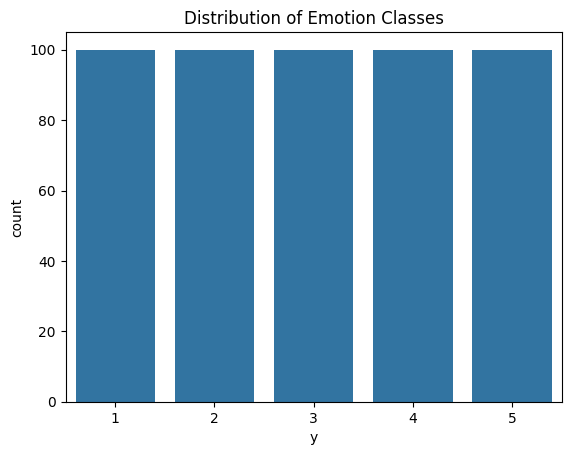

In [5]:
# Check the distribution of emotion classes

sns.countplot(x='y', data=df)
plt.title("Distribution of Emotion Classes")
plt.show()

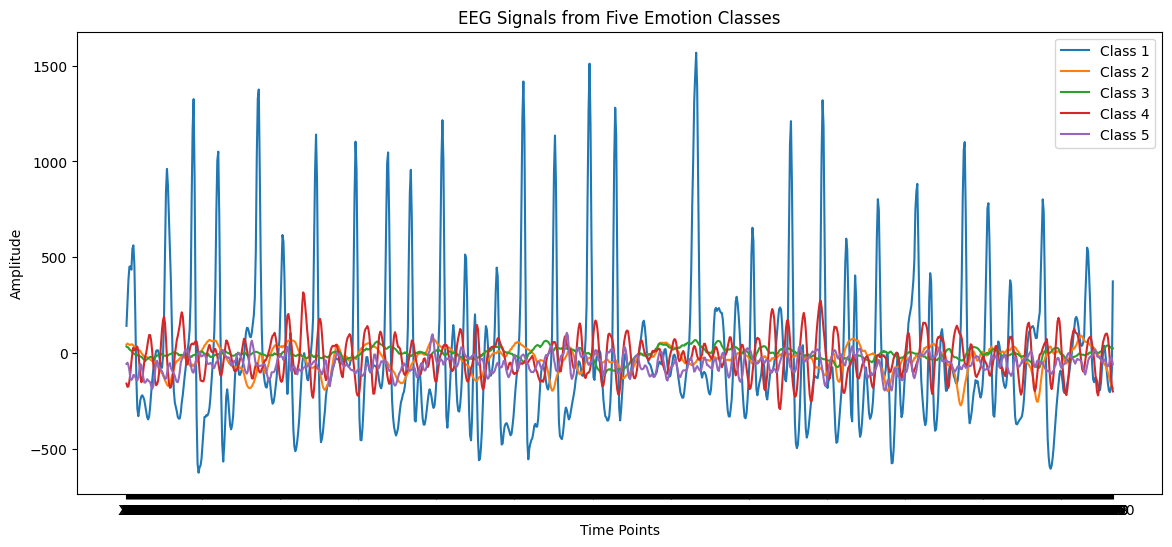

In [6]:
# Visualize Sample Signals from each class

# Define emotion classes
classes = [1, 2, 3, 4, 5]  # 1=Happy, 2=Sad, 3=Neutral, 4=Angry, 5=Fear

plt.figure(figsize=(14, 6))

# Plot one sample from each class
for c in classes:
    sample = df[df['y'] == c].iloc[0]  # take first sample of each class
    signal = sample['X1':'X1000']       # first 1000 time points for clarity
    plt.plot(signal, label=f"Class {c}")

plt.title("EEG Signals from Five Emotion Classes")
plt.xlabel("Time Points")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## 4. Data Cleaning

In [7]:
# Remove the first unnamed column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head(5)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,-56,-50,-64,-91,-135,-140,-134,-114,-115,-126,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,14,25,31,36,33,33,27,27,21,24,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,-159,-176,-174,-145,-101,-45,0,29,15,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,34,31,29,19,16,12,3,-1,-5,-8,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,44,50,46,43,43,46,45,40,36,31,...,4,5,6,6,2,1,0,-1,-4,2


## 5. Feature Selection

In [ ]:
# # Compute correlation matrix
# corr_matrix = df.drop(columns=['y']).corr().abs()
# corr_matrix
# # Select upper triangle
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# # Find columns with correlation > 0.95
# to_drop = [column for column in upper.columns if any(upper[column] > 0.96)]
# print("Dropping", len(to_drop), "highly correlated features")

# # Drop redundant features
# df_reduced = df.drop(columns=to_drop)

Dropping 657 highly correlated features


In [ ]:
# print(f'Size of reduced dataset is: {df_reduced.shape}')
# df_reduced.head(5)

Size of reduced dataset is: (500, 3438)


,X1,X2,X3,X6,X7,X8,X9,X10,X11,X12,...,X4084,X4085,X4086,X4087,X4089,X4090,X4091,X4092,X4093,y
0,-56,-50,-64,-140,-134,-114,-115,-126,-138,-143,...,-77,-49,-37,-43,-82,-114,-138,-159,-172,5
1,14,25,31,33,27,27,21,24,32,39,...,-67,-56,-45,-32,-7,-2,-20,-34,-40,5
2,-159,-176,-174,-45,0,29,15,15,29,34,...,-66,-56,-40,-25,56,73,48,-12,-62,4
3,34,31,29,12,3,-1,-5,-8,-8,-10,...,-28,-33,-34,-33,-22,-18,-14,-10,-9,3
4,44,50,46,46,45,40,36,31,26,21,...,-6,-4,4,5,6,2,1,0,-1,2


## **6. Dataset Splitting**


In [8]:
# Separate features and labels
X = df.drop("y", axis=1).values
y = df["y"].values

In [9]:
# Train-Test Split (STRATIFIED)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [10]:
# Apply Z-score normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

In [17]:
# Outlier Removal (on normalized training data)

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,   # assume ~5% outliers
    random_state=42
)

# Fit on TRAIN only
yhat = iso.fit_predict(X_train_scaled)

# Keep only inliers (1 = normal, -1 = outlier)
mask = yhat == 1

X_train_clean = X_train_scaled[mask]
y_train_clean = y_train[mask]

print("Before:", len(X_train_scaled))
print("After :", len(X_train_clean))

Before: 400
After : 380


Accuracy: 0.61


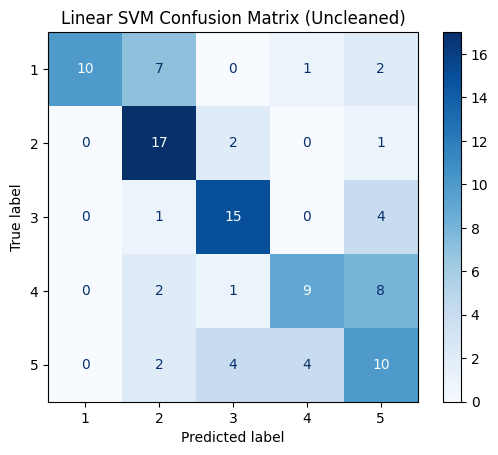

In [23]:
# Train Linear SVM (C = 1) — Uncleaned Data

from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1)
svm.fit(X_train_scaled, y_train)

# Predict
y_pred = svm.predict(X_test_scaled)


from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4, 5])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5]
)

disp.plot(cmap="Blues")
plt.title("Linear SVM Confusion Matrix (Uncleaned)")
plt.show()

Accuracy: 0.25


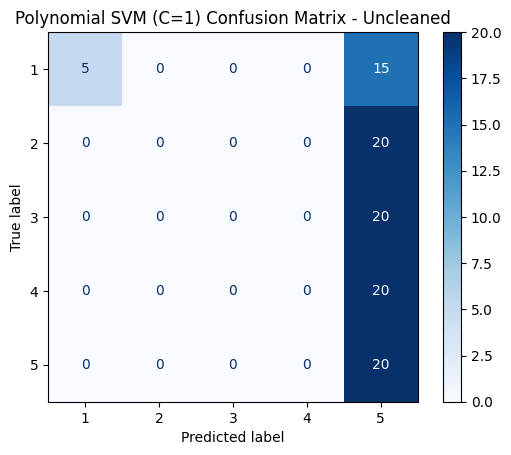

In [24]:
from sklearn.svm import SVC

svm = SVC(kernel='poly', C=1)
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4, 5])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5]
)

disp.plot(cmap="Blues")
plt.title("Polynomial SVM (C=1) Confusion Matrix - Uncleaned")
plt.show()


Linear SVM (Uncleaned) Accuracy: 0.61


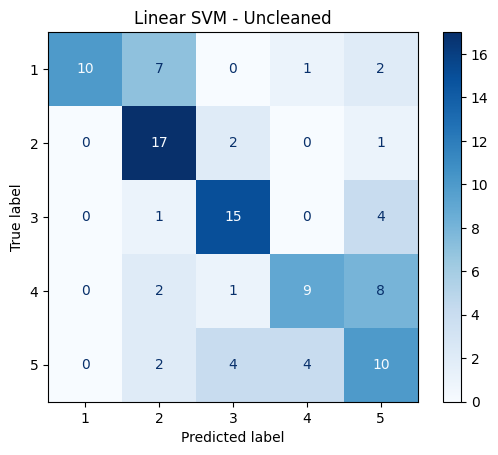


Linear SVM (Cleaned) Accuracy: 0.59


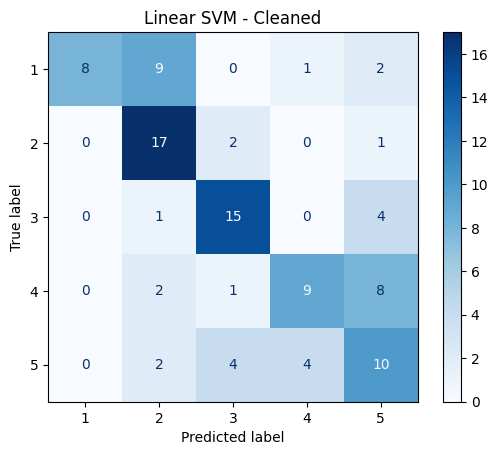


Polynomial SVM (Uncleaned) Accuracy: 0.25


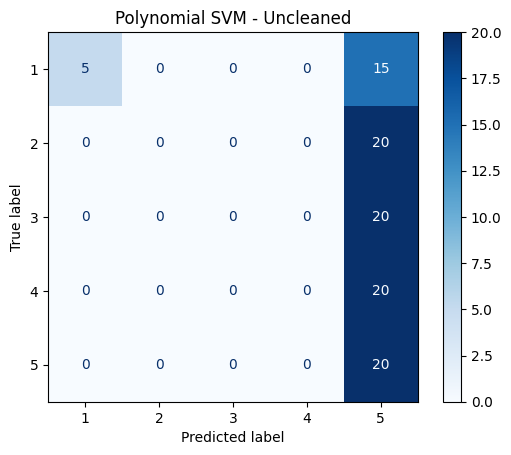


Polynomial SVM (Cleaned) Accuracy: 0.24


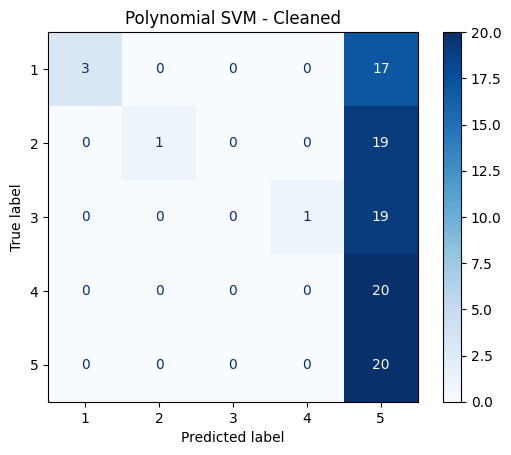

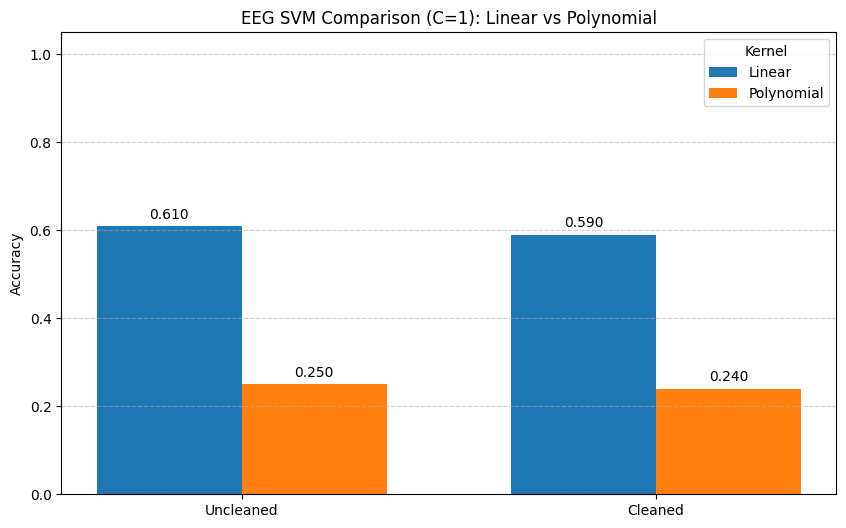

In [31]:

# =========================================================
# ===============  MODEL 1: LINEAR SVM ====================
# =========================================================

# -------- Uncleaned --------
svm_linear_unclean = SVC(kernel='linear', C=1)
svm_linear_unclean.fit(X_train_scaled, y_train)

y_pred_lu = svm_linear_unclean.predict(X_test_scaled)

print("\nLinear SVM (Uncleaned) Accuracy:",
      accuracy_score(y_test, y_pred_lu))

cm_lu = confusion_matrix(y_test, y_pred_lu, labels=[1,2,3,4,5])

ConfusionMatrixDisplay(cm_lu, display_labels=[1,2,3,4,5]).plot(cmap="Blues")
plt.title("Linear SVM - Uncleaned")
plt.show()


# -------- Cleaned --------
svm_linear_clean = SVC(kernel='linear', C=1)
svm_linear_clean.fit(X_train_clean, y_train_clean)

y_pred_lc = svm_linear_clean.predict(X_test_scaled)

print("\nLinear SVM (Cleaned) Accuracy:",
      accuracy_score(y_test, y_pred_lc))

cm_lc = confusion_matrix(y_test, y_pred_lc, labels=[1,2,3,4,5])

ConfusionMatrixDisplay(cm_lc, display_labels=[1,2,3,4,5]).plot(cmap="Blues")
plt.title("Linear SVM - Cleaned")
plt.show()


# =========================================================
# ============  MODEL 2: POLYNOMIAL SVM ===================
# =========================================================

# -------- Uncleaned --------
svm_poly_unclean = SVC(kernel='poly', C=1)
svm_poly_unclean.fit(X_train_scaled, y_train)

y_pred_pu = svm_poly_unclean.predict(X_test_scaled)

print("\nPolynomial SVM (Uncleaned) Accuracy:",
      accuracy_score(y_test, y_pred_pu))

cm_pu = confusion_matrix(y_test, y_pred_pu, labels=[1,2,3,4,5])

ConfusionMatrixDisplay(cm_pu, display_labels=[1,2,3,4,5]).plot(cmap="Blues")
plt.title("Polynomial SVM - Uncleaned")
plt.show()


# -------- Cleaned --------
svm_poly_clean = SVC(kernel='poly', C=1)
svm_poly_clean.fit(X_train_clean, y_train_clean)

y_pred_pc = svm_poly_clean.predict(X_test_scaled)

print("\nPolynomial SVM (Cleaned) Accuracy:",
      accuracy_score(y_test, y_pred_pc))

cm_pc = confusion_matrix(y_test, y_pred_pc, labels=[1,2,3,4,5])

ConfusionMatrixDisplay(cm_pc, display_labels=[1,2,3,4,5]).plot(cmap="Blues")
plt.title("Polynomial SVM - Cleaned")
plt.show()




import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# FINAL ACCURACY COLLECTION
# =========================================================

accuracy_lu = accuracy_score(y_test, y_pred_lu)
accuracy_lc = accuracy_score(y_test, y_pred_lc)
accuracy_pu = accuracy_score(y_test, y_pred_pu)
accuracy_pc = accuracy_score(y_test, y_pred_pc)

kernels = ['Linear', 'Polynomial']
data_types = ['Uncleaned', 'Cleaned']

accuracy_matrix = np.array([
    [accuracy_lu, accuracy_lc],
    [accuracy_pu, accuracy_pc]
])

# =========================================================
# PLOT SETUP
# =========================================================
x = np.arange(len(data_types))
width = 0.35

plt.figure(figsize=(10,6))

bars = []

for i, kernel in enumerate(kernels):
    bar = plt.bar(
        x + i * width,
        accuracy_matrix[i],
        width=width,
        label=kernel
    )
    bars.append(bar)

# =========================================================
# VALUE LABELS
# =========================================================
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

# =========================================================
# FORMATTING
# =========================================================
plt.xticks(x + width/2, data_types)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("EEG SVM Comparison (C=1): Linear vs Polynomial")
plt.legend(title="Kernel")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# =========================================================
# DATASETS (Clean vs Uncleaned)
# =========================================================

datasets = {
    "Uncleaned": (X_train_scaled, y_train),
    "Cleaned":   (X_train_clean, y_train_clean)
}

# External test set (same for both)
X_test_full = X_test_scaled
y_test_full = y_test

# =========================================================
# PARAMETER GRID
# =========================================================

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 2, 5]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 2, 5],
        "degree": [2, 3, 4]
    }
]

# =========================================================
# CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# GRID SEARCH LOOP
# =========================================================

grid_results = []

for data_name, (X_train, y_train_local) in datasets.items():

    grid = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train_local)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test_full)
    ext_accuracy = accuracy_score(y_test_full, y_pred)

    grid_results.append({
        "Dataset": data_name,
        "Best Params": grid.best_params_,
        "CV Best Score": grid.best_score_,
        "Test Accuracy": ext_accuracy
    })

# =========================================================
# RESULTS TABLE
# =========================================================

df_grid_results = pd.DataFrame(grid_results)
print(df_grid_results)

     Dataset                     Best Params  CV Best Score  Test Accuracy
0  Uncleaned  {'C': 0.1, 'kernel': 'linear'}       0.550000           0.61
1    Cleaned  {'C': 0.1, 'kernel': 'linear'}       0.518421           0.59


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# =========================================================
# DATASETS (Uncleaned vs Cleaned)
# =========================================================

datasets = {
    "Uncleaned": (X_train_scaled, y_train),
    "Cleaned":   (X_train_clean, y_train_clean)
}

# External test set (same for both)
X_test_full = X_test_scaled
y_test_full = y_test

# =========================================================
# RANDOM FOREST PARAMETER GRID
# =========================================================

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ['sqrt', 'log2'],
    "bootstrap": [True, False]
}

# =========================================================
# CROSS VALIDATION
# =========================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# GRID SEARCH LOOP
# =========================================================

grid_results_rf = []

for data_name, (X_train, y_train_local) in datasets.items():

    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train_local)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test_full)
    ext_accuracy = accuracy_score(y_test_full, y_pred)

    grid_results_rf.append({
        "Model": "Random Forest",
        "Dataset": data_name,
        "Best Params": grid.best_params_,
        "CV Best Score": grid.best_score_,
        "Test Accuracy": ext_accuracy
    })

# =========================================================
# RESULTS TABLE
# =========================================================

df_rf_results = pd.DataFrame(grid_results_rf)
print(df_rf_results)